<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 16 - Ejemplo 2 - Árboles de decisión
        </td>
    </tr>
    <tr>
 

</table>

Realizar los siguientes árboles de decisión sobre el conjunto de datos Wine y comentar
las diferencias que se observan entre ellos.

a) Sin ningún tipo de restricciones.

b) Indicando que el nivel de profundidad máximo permitido es de 3.

c) Indicando que el mínimo número de observaciones que debe contener cada nodo
hoja es de 4

Wine es un conjunto de datos que se puede encontrar en scikit-learn. Consiste en las
medidas químicas de varios tipos de vinos de una misma región de Italia producida
por tres fabricantes distintos. En concreto, contiene 13 variables predictoras y una
variable respuesta categórica con tres categorías: 0, 1 y 2 (que corresponden con los
distintos productores del vino). Para cargar el conjunto de datos se debe emplear la
función load_wine del modulo sklearn.datasets. Posteriormente cargamos el conjunto
de datos empleando dicha función. Para saber más sobre las variables que componen
el conjunto de datos, podemos modificar el argumento as_frame = True, para que se
cargue como un data.frame y así poder emplear los métodos de la librería pandas

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt

#Cargar dataset
wine = load_wine(as_frame = True)

In [2]:
#Ver variables predictoras wine
wine.data.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: float64(13)
m

In [3]:
wine.target.value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

Se observa que el conjunto de datos Wine contiene 178 observaciones de 13 variables
predictoras y que la variable respuesta categórica contiene 59 veces la categoría 0, 71
veces la categoría 1, y 48 veces la categoría 2

In [4]:
from sklearn.tree import DecisionTreeClassifier

#Seleccionar todas las variables
X = wine.data
#Especie de la planta

y = wine.target
#Crear el objeto de clase árbol
tree_clf = DecisionTreeClassifier(random_state = 2026)
#Ajustar el arbol
tree_clf.fit(X, y);

In [ ]:
from sklearn import tree
plt.figure(figsize=(14,10))
tree.plot_tree(tree_clf,filled=True)

Podemos ver que este árbol de decisión es muy largo y seguramente presentará un sobreajuste si se emplease ante observaciones que no se han utilizado para la construcción
del modelo.

In [5]:
from sklearn.metrics import accuracy_score

#Obtener el accuracy_score
y_pred_1 = tree_clf.predict(X)
accuracy_1 = accuracy_score(y, y_pred_1)
print("El accuracy score que se tiene es %s" %accuracy_1)

El accuracy score que se tiene es 1.0


Text(50.722222222222214, 0.5, 'Real')

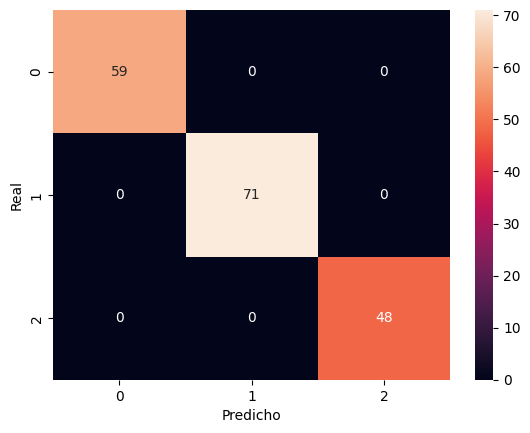

In [6]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y, y_pred_1)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_1 = precision_score(y, y_pred_1,average="macro")
recall_1 = recall_score(y, y_pred_1, average="macro")
f1_1 = f1_score(y, y_pred_1, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_1, recall_1,f1_1]})
metricas

,Métricas,Valores
0,Precisión,1.0
1,Recall,1.0
2,F1,1.0


b) Indicando que el nivel de profundidad máximo permitido es de 3.

In [25]:
#Crear el objeto de clase arbol
tree_clf_b =  DecisionTreeClassifier(max_depth=3, random_state=2026)
# Ajustar el arbol
tree_clf_b.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",2026
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

Ahora, se va a restringir la longitud de las ramas del árbol fijando el número máximo
de profundidad max_depth = 3.

[Text(0.5, 0.875, 'x[12] <= 755.0\ngini = 0.658\nsamples = 178\nvalue = [59.0, 71.0, 48.0]'),
 Text(0.25, 0.625, 'x[11] <= 2.115\ngini = 0.492\nsamples = 111\nvalue = [2, 67, 42]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[10] <= 0.935\ngini = 0.227\nsamples = 46\nvalue = [0, 6, 40]'),
 Text(0.0625, 0.125, 'gini = 0.049\nsamples = 40\nvalue = [0, 1, 39]'),
 Text(0.1875, 0.125, 'gini = 0.278\nsamples = 6\nvalue = [0, 5, 1]'),
 Text(0.375, 0.375, 'x[6] <= 0.795\ngini = 0.117\nsamples = 65\nvalue = [2, 61, 2]'),
 Text(0.3125, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 0, 2]'),
 Text(0.4375, 0.125, 'gini = 0.061\nsamples = 63\nvalue = [2, 61, 0]'),
 Text(0.75, 0.625, 'x[6] <= 2.165\ngini = 0.265\nsamples = 67\nvalue = [57, 4, 6]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[6] <= 0.9\ngini = 0.375\nsamples = 8\nvalue = [0, 2, 6]'),
 Text(0.5625, 0.125, 'gini = 0.0\nsamples = 6\nvalue = [0, 0, 6]'),
 Text(0.6875, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2, 0]'),

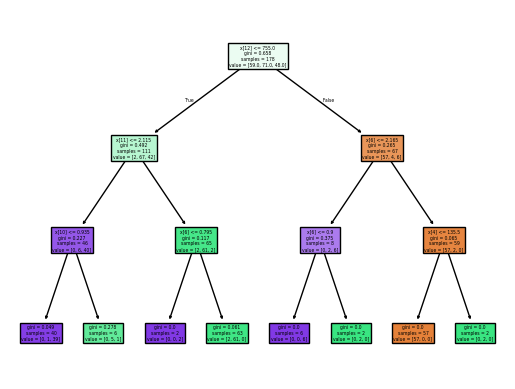

In [26]:
from sklearn import tree
tree.plot_tree(tree_clf_b,filled=True)

Una vez que se ha ajustado el árbol, se genera el gráfico

In [19]:
#obtener el accuracy_score
y_pred_b= tree_clf_b.predict(X)
accuracy_b = accuracy_score(y, y_pred_b)
print("El accuracy score que se tiene es %s" %accuracy_b)

El accuracy score que se tiene es 0.9775280898876404


Text(50.722222222222214, 0.5, 'Real')

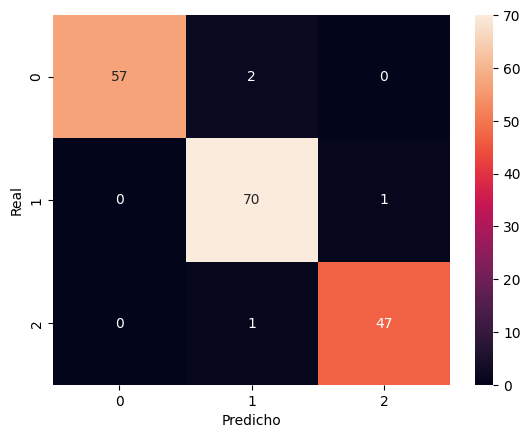

In [20]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y, y_pred_b)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_b = precision_score(y, y_pred_b,average="macro")
recall_b = recall_score(y, y_pred_b, average="macro")
f1_b = f1_score(y, y_pred_b, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_b, recall_b,f1_b]})
metricas

,Métricas,Valores
0,Precisión,0.979357
1,Recall,0.977061
2,F1,0.978049


c) Indicando que el mínimo número de observaciones que debe contener cada nodo
hoja es de 4.

In [12]:
#Crear el objeto de clase arbol
tree_clf_c =  DecisionTreeClassifier(min_samples_leaf=4, random_state=2026) #4 muestras
# Ajustar el arbol
tree_clf_c.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",2026
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

Otra manera de restringir la longitud del árbol de decisión sin fijar la profundidad
máxima es indicando el número mínimo de observaciones que debe contener cada
nodo hoja. En este caso se fijará el valor de min_samples_leaf = 4.

[Text(0.5294117647058824, 0.9, 'x[12] <= 755.0\ngini = 0.658\nsamples = 178\nvalue = [59.0, 71.0, 48.0]'),
 Text(0.29411764705882354, 0.7, 'x[11] <= 2.115\ngini = 0.492\nsamples = 111\nvalue = [2, 67, 42]'),
 Text(0.4117647058823529, 0.8, 'True  '),
 Text(0.17647058823529413, 0.5, 'x[10] <= 0.935\ngini = 0.227\nsamples = 46\nvalue = [0, 6, 40]'),
 Text(0.11764705882352941, 0.3, 'x[8] <= 1.59\ngini = 0.049\nsamples = 40\nvalue = [0, 1, 39]'),
 Text(0.058823529411764705, 0.1, 'gini = 0.0\nsamples = 36\nvalue = [0, 0, 36]'),
 Text(0.17647058823529413, 0.1, 'gini = 0.375\nsamples = 4\nvalue = [0, 1, 3]'),
 Text(0.23529411764705882, 0.3, 'gini = 0.278\nsamples = 6\nvalue = [0, 5, 1]'),
 Text(0.4117647058823529, 0.5, 'x[0] <= 12.805\ngini = 0.117\nsamples = 65\nvalue = [2, 61, 2]'),
 Text(0.35294117647058826, 0.3, 'gini = 0.0\nsamples = 55\nvalue = [0, 55, 0]'),
 Text(0.47058823529411764, 0.3, 'x[4] <= 95.0\ngini = 0.56\nsamples = 10\nvalue = [2, 6, 2]'),
 Text(0.4117647058823529, 0.1, 'gini

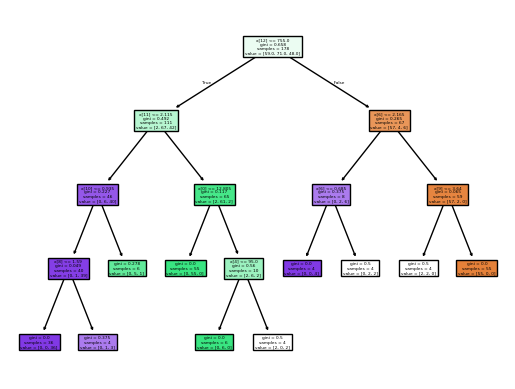

In [13]:
from sklearn import tree
tree.plot_tree(tree_clf_c,filled=True)

In [22]:
#obtener el accuracy_score
y_pred_c= tree_clf_c.predict(X)
accuracy_c = accuracy_score(y, y_pred_c)
print("El accuracy score que se tiene es %s" %accuracy_c)

El accuracy score que se tiene es 0.9550561797752809


Text(50.722222222222214, 0.5, 'Real')

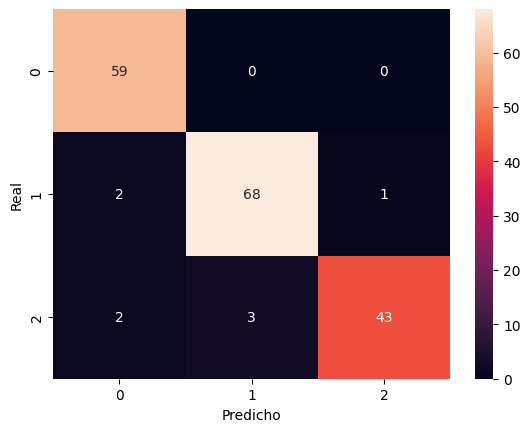

In [23]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y, y_pred_c)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener la presición, recall y f1
precision_c = precision_score(y, y_pred_c,average="macro")
recall_c = recall_score(y, y_pred_c, average="macro")
f1_c = f1_score(y, y_pred_c, average="macro")

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_c, recall_c,f1_c]})
metricas

,Métricas,Valores
0,Precisión,0.957176
1,Recall,0.951193
2,F1,0.953247
